In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import io
import geopandas as gpd
import zipfile
import os
from pathlib import Path
import tempfile
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import urllib3
# quieten HTTP certificate verification warnings
urllib3.disable_warnings()

from cellmander.dataloader import download_alarm_csv, read_alarm_csv, extract_vote_totals
from cellmander.spatial import download_tiger_vtd, read_vtd_shapefile, compute_centroids_and_join

In [3]:
state_abbr = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "DC", "FL",
    "GA", "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME",
    "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH",
    "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", 
    "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", 
    "WY",
]

In [4]:
for state in tqdm(state_abbr):
    if state in ["HI", "AK"]:
        print(f"Skipping {state} for map continuity reasons")
        continue
    try:
        state = state.lower()  # Convert to lowercase for consistency
        # 1. download ALARM CSV with vote counts per party
        csv_path = download_alarm_csv(state, dest_dir='data/alarm')
        df_raw = read_alarm_csv(csv_path)
        df_votes = extract_vote_totals(df_raw)  # DataFrame with GEOID20 + vote totals

        # 2. download TIGER VTD shapefile for NC and read
        zip_path = download_tiger_vtd(state, dest_dir='data/shapefiles')
        vtd_gdf = read_vtd_shapefile(zip_path)

        # 3. join and compute centroids (x,y in EPSG:5070)
        joined = compute_centroids_and_join(df_votes, vtd_gdf, keep_geometry=False)

        # joined now has columns: state_id, county_id, voting_district, GEOID20, n_vote_dem_2020, n_vote_rep_2020, x, y
        save_dir = 'data/processed'
        os.makedirs(save_dir, exist_ok=True)
        joined.to_csv(f"{save_dir}/{state}_vtd_with_xy.csv", index=False)
    except Exception as e:
        # FIXME: CA and OR did not voluntarily participate. Reconstruct from TABLOCK files instead
        
        print(f"Error processing state {state}: {e}")
        continue

  0%|                                                                                                | 0/51 [00:00<?, ?it/s]

  2%|█▋                                                                                      | 1/51 [00:00<00:41,  1.20it/s]

Skipping AK for map continuity reasons


 10%|████████▋                                                                               | 5/51 [00:09<02:09,  2.81s/it]

Error processing state ca: 404 Client Error: Not Found for url: https://www2.census.gov/geo/tiger/TIGER2020PL/LAYER/VTD/2020/tl_2020_06_vtd20.zip


 22%|██████████████████▊                                                                    | 11/51 [00:12<00:33,  1.20it/s]

Skipping HI for map continuity reasons


 75%|████████████████████████████████████████████████████████████████▊                      | 38/51 [00:30<00:16,  1.25s/it]

Error processing state or: 404 Client Error: Not Found for url: https://www2.census.gov/geo/tiger/TIGER2020PL/LAYER/VTD/2020/tl_2020_41_vtd20.zip


100%|███████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:39<00:00,  1.30it/s]


### Minnesota Case Study

In [5]:
def read_data_folder(folder_path):
    """
    Read data from a folder containing CSV and ZIP files.
    
    Args:
        folder_path (str): Path to the folder containing data files
    """
    folder_path = Path(folder_path)
    
    if not folder_path.exists():
        raise FileNotFoundError(f"Folder {folder_path} does not exist")
    
    csv_dataframes = []
    shp_geodataframes = []
    
    # Process all files in the folder
    for file_path in folder_path.iterdir():
        if file_path.is_file():
            
            # Handle CSV files
            if file_path.suffix.lower() == '.csv':
                try:
                    df = pd.read_csv(file_path)
                    csv_dataframes.append(df)
                except Exception as e:
                    print(f"Error reading CSV file {file_path.name}: {e}")
            
            # Handle ZIP files
            elif file_path.suffix.lower() == '.zip':
                try:
                    with tempfile.TemporaryDirectory() as temp_dir:
                        # Extract ZIP file
                        with zipfile.ZipFile(file_path, 'r') as zip_ref:
                            zip_ref.extractall(temp_dir)
                        
                        # Look for .shp files in extracted content
                        temp_path = Path(temp_dir)
                        for extracted_file in temp_path.rglob("*.shp"):
                            try:
                                gdf = gpd.read_file(extracted_file)
                                shp_geodataframes.append(gdf)
                            except Exception as e:
                                print(f"Error reading shapefile {extracted_file.name}: {e}")
                
                except Exception as e:
                    print(f"Error processing ZIP file {file_path.name}: {e}")
    
    # Combine all CSV dataframes
    combined_csv = None
    if csv_dataframes:
        try:
            combined_csv = pd.concat(csv_dataframes, ignore_index=True)
            return combined_csv
        except Exception as e:
            print(f"Error combining CSV files: {e}")
    
    combined_geodataframes = None
    if shp_geodataframes:
        try:
            combined_gdf = gpd.GeoDataFrame(pd.concat(shp_geodataframes, ignore_index=True), crs=shp_geodataframes[0].crs)
            return combined_gdf
        except Exception as e:
            print(f"Error combining shapefiles: {e}")

<Axes: title={'center': 'Number of Voting Districts by State'}, xlabel='state_id'>

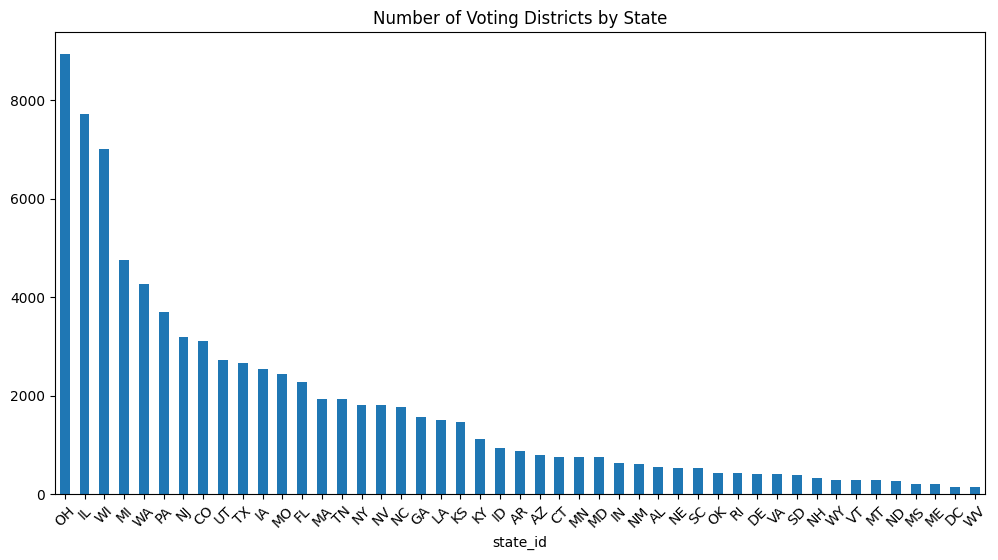

In [6]:
vtd_votes_df = read_data_folder('data/processed')
vtd_votes_df.groupby('state_id')['voting_district'].nunique().sort_values(ascending=False).plot(kind='bar', figsize=(12, 6), rot=45, title='Number of Voting Districts by State')

In [7]:
def plot_vtd_centroids(vtd_votes_csv_path, vtd_gdf_path, output_path=None, state=None):
    """
    Plot VTD centroids across US given vote counts and shapefile geometry.
    """
    vtd_votes_df = read_data_folder(vtd_votes_csv_path)
    merged_vtd_gdf = read_data_folder(vtd_gdf_path)
    
    # Ensure GEOID20 exists in both for merge
    merged = merged_vtd_gdf.merge(vtd_votes_df, on="GEOID20", how="left")
    if state:
        merged = merged[merged['state_id'] == state]

    # Calculate fraction of Democratic votes
    merged['total_votes'] = merged['n_vote_dem_2020'] + merged['n_vote_rep_2020']
    merged['dem_fraction'] = merged['n_vote_dem_2020'] / merged['total_votes']
    # Handle NaN values (set to 0.5 for neutral color)
    merged['dem_fraction'] = merged['dem_fraction'].fillna(0.5)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    merged.plot(
        ax=ax, 
        column='dem_fraction', cmap='coolwarm', alpha=0.3, vmin=0, vmax=1,
        linewidth=0.5, edgecolor="black")
    
    # Compute centroids
    merged["centroid"] = merged.geometry.centroid
    centroid_gdf = gpd.GeoDataFrame(merged, geometry="centroid", crs=merged.crs)
    centroid_gdf.plot(ax=ax, markersize=0.5, color="red", alpha=0.3)
    
    ax.set_title(f"2020 Voting Districts {state if state else ''}", fontsize=16)
    ax.axis("off")
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    return merged

/tmp/ipykernel_1177737/232816483.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged["centroid"] = merged.geometry.centroid


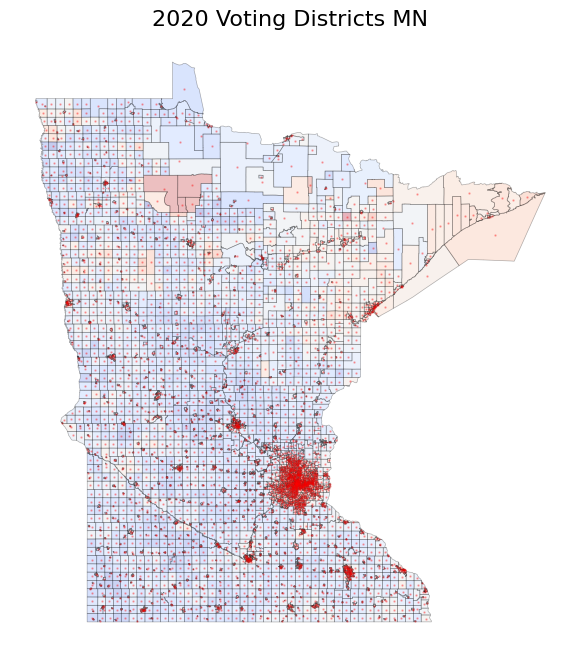

In [8]:
gdf = plot_vtd_centroids(
    vtd_votes_csv_path='data/processed',
    vtd_gdf_path='data/shapefiles',
    state='MN'
)

In [9]:
gdf.head(3)

,STATEFP20,COUNTYFP20,VTDST20,GEOID20,VTDI20,NAME20,NAMELSAD20,LSAD20,MTFCC20,FUNCSTAT20,...,state_id,county_id,voting_district,n_vote_dem_2020,n_vote_rep_2020,x,y,total_votes,dem_fraction,centroid
10275,27,015,000005,27015000005,A,Albin Twp,Albin Twp,00,G5240,N,...,MN,Brown County,000005,38.9,123.4,105320.391291,2.352046e+06,162.3,0.239680,POINT (-94.6791 44.15242)
10276,27,015,000010,27015000010,A,Bashaw Twp,Bashaw Twp,00,G5240,N,...,MN,Brown County,000010,29.0,92.6,86105.170428,2.351769e+06,121.6,0.238487,POINT (-94.92011 44.15211)
10277,27,015,000015,27015000015,A,Burnstown Twp,Burnstown Twp,00,G5240,N,...,MN,Brown County,000015,29.5,101.0,85595.113050,2.361425e+06,130.5,0.226054,POINT (-94.92514 44.23878)


# Simulating election maps with Gerrychain

In [10]:
from gerrychain import (Partition, Graph, MarkovChain,
                        updaters, constraints, accept,
                        GeographicPartition)
from gerrychain.proposals import recom
from gerrychain.tree import bipartition_tree
from gerrychain.constraints import contiguous
from functools import partial

import random
random.seed(42)

In [11]:
# load Minnesota precincts
graph = Graph.from_file("data/gerrychain_eg/MN_precincts.geojson")

# updater track metrics of interest
my_updaters = {
    "population": updaters.Tally("TOTPOP", alias="population"),
    "cut_edges": updaters.cut_edges, # get cut edges set for proposal function
    "perimeter": updaters.perimeter,
    "area": updaters.Tally("area", alias="area"),
}

# create an initial partition
initial_partition = GeographicPartition(
    graph,
    assignment="CONGDIST",
    updaters=my_updaters
)

<Axes: title={'center': 'Initial Partition in MN'}>

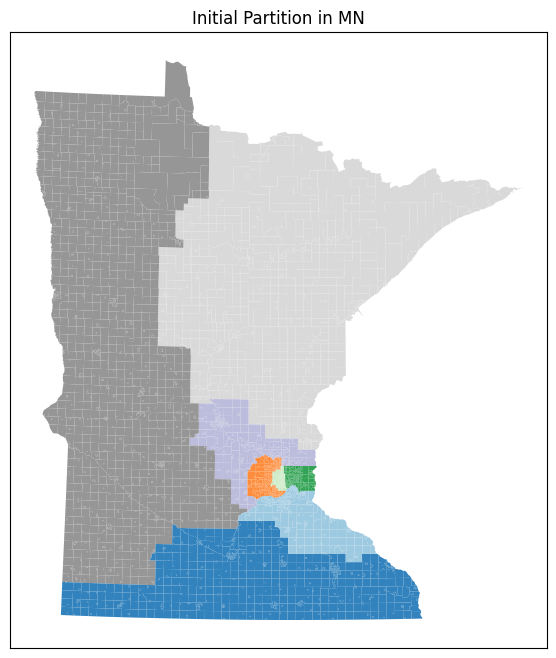

In [12]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Initial Partition in MN")
initial_partition.plot(ax=ax, cmap='tab20c')

In [27]:
# run a Markov chain
ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)

proposal = partial(
    recom, # use the recom method
    pop_col="TOTPOP",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2,
    # region_surcharge = ... # keep regions together (e.g. counties)
)

recom_chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=accept.always_accept, # implement Metropolis-Hastings here
    initial_state=initial_partition,
    total_steps=1000,
)

In [28]:
%matplotlib inline
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png')
from scipy.optimize import linear_sum_assignment
from PIL import Image

def _digits_only(s):
    s = str(s)
    return "".join(ch for ch in s if ch.isdigit())

def _countyfp3(val):
    if val is None:
        return None
    s = _digits_only(val)
    # Handle 5-digit FIPS like 27015 by taking last 3, or 3-digit like 015 by padding
    return (s[-3:] if len(s) >= 3 else s.zfill(3))

def _vtdst6(data):
    # Prefer explicit 2020 field if present; fall back to PCTCODE or VTDID
    for k in ("VTDST20", "PCTCODE", "VTDID"):
        if k in data and data[k] is not None:
            ds = _digits_only(data[k])
            if ds:
                return (ds[-6:] if len(ds) >= 6 else ds.zfill(6))
    return None


def get_district_centroid(partition, district_id):
    """Get the geographic centroid of a district"""
    nodes_in_district = [n for n in partition.graph.nodes() if partition.assignment[n] == district_id]
    if not nodes_in_district:
        return None
    
    # Get centroids from node geometry
    centroids = []
    for node in nodes_in_district:
        node_data = partition.graph.nodes[node]
        
        # Use geometry field - this is what your data has
        if 'geometry' in node_data and node_data['geometry'] is not None:
            geom = node_data['geometry']
            if hasattr(geom, 'centroid'):
                centroids.append((geom.centroid.x, geom.centroid.y))
    
    if centroids:
        avg_x = sum(c[0] for c in centroids) / len(centroids)
        avg_y = sum(c[1] for c in centroids) / len(centroids)
        return (avg_x, avg_y)
    
    return None


def match_districts_between_steps(prev_districts, curr_districts):
    """Match district IDs between consecutive steps using Hungarian algorithm"""
    if not prev_districts or not curr_districts:
        return {}
    
    # Create cost matrix based on geographic overlap or similarity
    cost_matrix = np.zeros((len(prev_districts), len(curr_districts)))
    
    # Fill cost matrix (lower = more similar)
    for i, (prev_id, prev_centroid) in enumerate(prev_districts.items()):
        for j, (curr_id, curr_centroid) in enumerate(curr_districts.items()):
            if prev_centroid and curr_centroid:
                # Use Euclidean distance as cost
                dist = np.sqrt((prev_centroid[0] - curr_centroid[0])**2 + 
                              (prev_centroid[1] - curr_centroid[1])**2)
                cost_matrix[i, j] = dist
            else:
                cost_matrix[i, j] = float('inf')
    
    # Solve assignment problem
    row_indices, col_indices = linear_sum_assignment(cost_matrix)
    
    # Create mapping from current district IDs to consistent labels
    prev_ids = list(prev_districts.keys())
    curr_ids = list(curr_districts.keys())
    
    mapping = {}
    for i, j in zip(row_indices, col_indices):
        mapping[curr_ids[j]] = prev_ids[i]  # Map current ID to previous ID
    
    return mapping


MN_STATEFP = "27"
frames = []
district_data = []
assignment_rows = []
prev_district_centroids = None

# iterate through markov chain and collect data
for i, partition in tqdm(enumerate(recom_chain), total=recom_chain.total_steps):
    # calculate district centroids at each step and use the Hungarian algorithm to match district IDs since gerrychain randomly assigns them
    curr_district_centroids = {}
    for district_name in partition.parts:
        centroid = get_district_centroid(partition, district_name)
        curr_district_centroids[district_name] = centroid
    
    # Match districts to previous step (if not first step)
    district_mapping = {}
    if i > 0 and prev_district_centroids:
        district_mapping = match_districts_between_steps(
            prev_district_centroids, curr_district_centroids
        )
    else:
        # First step - use original IDs
        district_mapping = {k: k for k in curr_district_centroids.keys()}
    
    # Collect data using consistent labels
    for district_name in partition.perimeter.keys():
        consistent_label = district_mapping.get(district_name, district_name)
        population = partition.population[district_name]
        perimeter = partition.perimeter[district_name]
        area = partition.area[district_name]
        district_data.append((i, consistent_label, population, perimeter, area))
    
    # Update for next iteration
    prev_district_centroids = {district_mapping.get(k, k): v 
                              for k, v in curr_district_centroids.items()}
        
    assign = partition.assignment
    for n, data in partition.graph.nodes(data=True):
        statefp = data.get("STATEFP20", MN_STATEFP)
        statefp = str(statefp).zfill(2)
        countyfp = _countyfp3(data.get("COUNTYFP20", data.get("COUNTYFIPS")))
        vtdst = _vtdst6(data)
        geoid20 = f"{statefp}{countyfp}{vtdst}" if statefp and countyfp and vtdst else None

        assignment_rows.append({
            "step": i,
            "district_name": str(district_mapping[assign[n]]),
            "node_id": n,
            # Join keys compatible with ALARM
            "STATEFP20": statefp,
            "COUNTYFP20": countyfp,
            "VTDST20": vtdst,
            "GEOID20": geoid20,
            # Helpful aliases used in your ALARM-processed CSVs
            "county_id": (f"{data.get('COUNTYNAME')} County" if data.get("COUNTYNAME") else None),
            "voting_district": vtdst,
            # Optional context from the graph
            "COUNTYNAME": data.get("COUNTYNAME"),
            "COUNTYFIPS": data.get("COUNTYFIPS"),
            "PCTCODE": data.get("PCTCODE"),
            "PCTNAME": data.get("PCTNAME"),
        })

    buffer = io.BytesIO()
    fig, ax = plt.subplots(figsize=(10,8))
    partition.plot(ax=ax, cmap='tab20c')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.savefig(buffer, format='png', bbox_inches='tight')
    buffer.seek(0)
    image = Image.open(buffer)
    frames.append(image)
    plt.close(fig)

df = pd.DataFrame(
    district_data,
    columns=[
        'step',
        'district_name',
        'population',
        'perimeter',
        'area'
    ]
)

assignment_df = pd.DataFrame(assignment_rows)

100%|█████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [18:08<00:00,  1.09s/it]


In [ ]:
# make an animation
import ipywidgets as widgets
from ipywidgets import Play, IntSlider, HBox, jslink, Output
from IPython.display import display, clear_output


out = Output()

def show_frame(idx):
    with out:
        clear_output(wait=True)
        display(frames[idx])

# Controls
play = Play(interval=300, value=0, min=0, max=len(frames)-1, step=1, description="Play")
slider = IntSlider(value=0, min=0, max=len(frames)-1, step=1, description='Frame:')
slider.layout.width = '500px'

# Link playhead <-> slider
jslink((play, 'value'), (slider, 'value'))

# Update display when slider changes
def _on_change(change):
    if change['name'] == 'value':
        show_frame(change['new'])
slider.observe(_on_change, names='value')

# Initial frame and UI
show_frame(0)
display(HBox([play, slider]), out)

Output()

In [36]:
# export as a gif
from IPython.display import Image as IPyImage, display

out_dir = "plots/"
os.makedirs(out_dir, exist_ok=True)
gif_path = os.path.join(out_dir, "mn_recom.gif")

stride = 5 # Downsample to reduce size
duration_ms = 300 

export_frames = frames[::stride]
export_frames_8bit = [im.convert("P", palette=Image.ADAPTIVE, colors=256) for im in export_frames]
export_frames_8bit[0].save(
    gif_path,
    save_all=True,
    append_images=export_frames_8bit[1:],
    duration=duration_ms,
    loop=0,
    optimize=True)

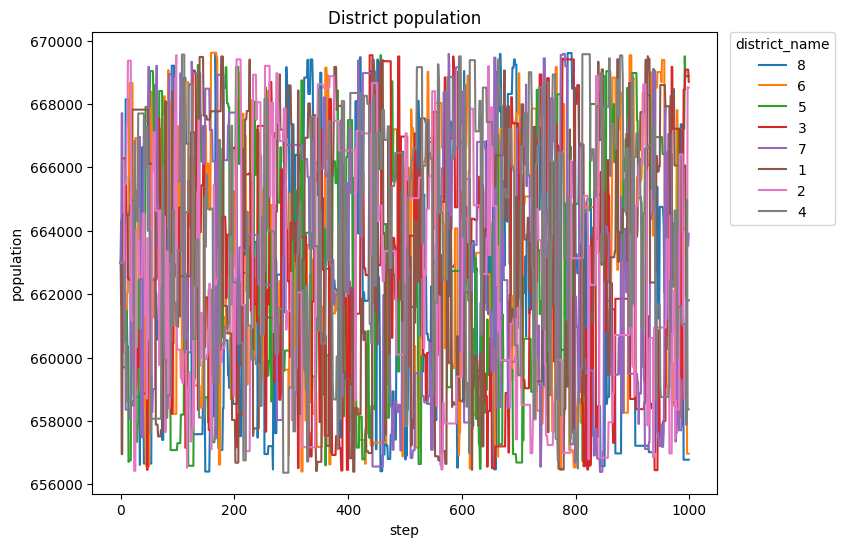

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(df, x='step', y='population', hue='district_name', ax=ax)
ax.legend(title='district_name', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
ax.set_title('District population')
plt.subplots_adjust(right=0.75)

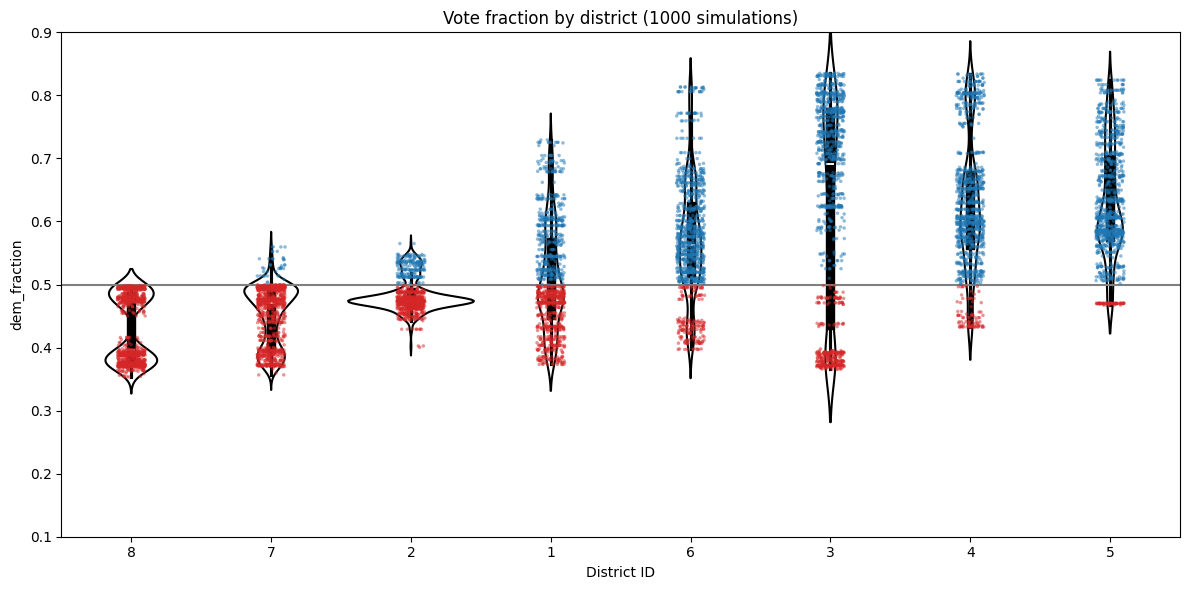

In [31]:
plot_df = assignment_df.merge(
    gdf[['GEOID20', 'n_vote_dem_2020', 'n_vote_rep_2020']],
    on='GEOID20', how='left'
).groupby(
    ['district_name', 'step']
).agg({
    'n_vote_dem_2020': 'sum',
    'n_vote_rep_2020': 'sum'
}).reset_index()

# calculate party vote fraction
plot_df['dem_fraction'] = plot_df['n_vote_dem_2020'] / (plot_df['n_vote_dem_2020'] + plot_df['n_vote_rep_2020'])
order = plot_df.groupby('district_name')['dem_fraction'].mean().sort_values().index.tolist()
plot_df['half_label'] = np.where(plot_df['dem_fraction'] > 0.5, 'Above 0.5', 'Below 0.5')
palette = {'Above 0.5': 'tab:blue', 'Below 0.5': 'tab:red'}

plt.figure(figsize=(12, 6))

# # small number of steps
# ax = sns.boxplot(data=plot_df, x='district_name', y='dem_fraction', order=order, width=0.6, fill=False, showfliers=False)
# sns.swarmplot(data=plot_df, x='district_name', y='dem_fraction', order=order, ax=ax, size=2.5)

# large number of steps
ax = sns.stripplot(
    data=plot_df, x='district_name', y='dem_fraction', order=order, size=2.5, jitter=True, alpha=0.5, hue='half_label', palette=palette
)
sns.violinplot(
    data=plot_df, x='district_name', y='dem_fraction', order=order, width=0.9, fill=False, ax=ax, color='black'
)
ax.legend_.remove()  # Disable legend
plt.ylim(0.1, 0.9)

plt.axhline(0.5, color='gray')
plt.title(f'Vote fraction by district ({recom_chain.total_steps} simulations)')
plt.xlabel('District ID')
plt.tight_layout()
plt.show()

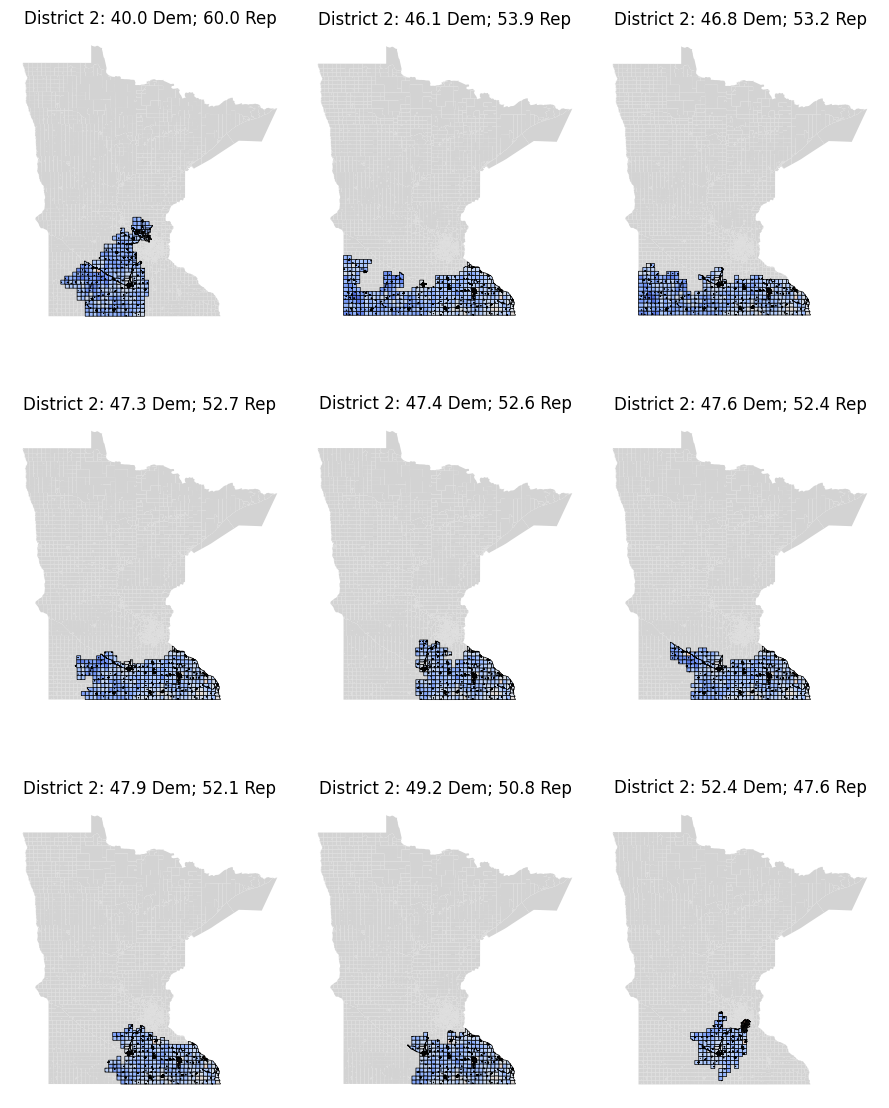

In [35]:
# visualize a single district
district = '2'

samples_order = plot_df[plot_df['district_name'] == district].sort_values(by='dem_fraction').reset_index(drop=True)

fig, ax = plt.subplots(3, 3, figsize=(9, 12))
ax = ax.flatten()
for i in range(len(ax)):
    idx = len(samples_order) // len(ax) * i
    step = samples_order['step'][idx]
    dem_fraction = samples_order['dem_fraction'][idx] 

    # get geoid20s for this district at this step
    district_geoid20 = assignment_df[(assignment_df['district_name'] == district) & (assignment_df['step'] == step)]['GEOID20'].values

    # plot the map in gray
    gdf.plot(ax=ax[i], color='lightgray')
    # plot the district with voting fraction for vtds
    district_gdf = gdf[gdf['GEOID20'].isin(district_geoid20)]
    district_gdf.plot(
        ax=ax[i], 
        column='dem_fraction', cmap='coolwarm', vmin=0, vmax=1,
        linewidth=0.5, edgecolor="black"
    )

    ax[i].set_title(f"District {district}: {dem_fraction*100:.1f} Dem; {100 - dem_fraction*100:.1f} Rep")
    ax[i].axis('off')

plt.tight_layout()
plt.show()